In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [47]:
lena = cv2.imread("./test_assets/landscape.jpg", 0)


cv2.imshow("Lena", lena)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [48]:
landscape=cv2.imread("./test_assets/landscape2.jpeg",1)

custom_width = 600
custom_height = 450
resized_landscape = cv2.resize(landscape, (custom_width, custom_height))
cv2.imshow("Landscape", resized_landscape)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [49]:
def histogram_equalization(image):
    M,N=image.shape
    total_pixels = M*N
    L=256
    # histogram = np.zeros(L, dtype=np.int32)
    # for i in range(M):
    #     for j in range(N):
    #         pixel_intensity=image[i,j]
    #         histogram[pixel_intensity] += 1
    histogram=cv2.calcHist([image], [0], None, [256], [0,256]).flatten()

    probability=np.zeros(L, dtype=np.float32)
    for i in range(L):
        probability[i] = histogram[i]/total_pixels
    
    cumulative_sum_array=np.zeros(L, dtype=np.float32)
    transformation_fn=np.zeros(L, dtype=np.int32)
    for i in range(L):
        cumulative_sum=0.0
        for j in range(i+1):
            cumulative_sum += probability[j]
        cumulative_sum_array[i] = cumulative_sum
        transformation_fn[i] = round((L-1)*cumulative_sum)
        if transformation_fn[i]>255:
            transformation_fn[i]=255

    equalized_image=np.zeros_like(image)
    for i in range(M):
        for j in range(N):
            old_value=image[i,j]
            new_value=transformation_fn[old_value]
            equalized_image[i,j]=new_value
    
    equalized_hist=np.zeros(L, dtype=np.int32)
    for i in range(M):
        for j in range(N):
            pixel_intensity=equalized_image[i,j]
            equalized_hist[pixel_intensity] += 1

    return histogram, probability, cumulative_sum_array, transformation_fn, equalized_image, equalized_hist


In [50]:
hist, prob, cum_sum_array, trans_fn, equalized, equalized_hist = histogram_equalization(lena)

In [51]:
print("Original Histogram:\n", hist)
print("Probability Distribution:\n", prob)
print("Cumulative Distribution Function:\n", cum_sum_array)
print("Transformation Function:\n", trans_fn)
print("Equalized Image:\n", equalized)
print("Equalized Histogram:\n", equalized_hist)

Original Histogram:
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
 2.000e+00 2.000e+00 8.000e+00 9.000e+00 1.200e+01 2.100e+01 4.100e+01
 6.700e+01 1.130e+02 1.700e+02 2.440e+02 3.360e+02 4.590e+02 5.370e+02
 6.600e+02 8.150e+02 8.140e+02 9.740e+02 1.187e+03 1.356e+03 1.651e+03
 1.942e+03 2.304e+03 2.740e+03 3.032e+03 3.599e+03 4.098e+03 4.573e+03
 5.191e+03 5.729e+03 6.573e+03 7.014e+03 7.873e+03 8.450

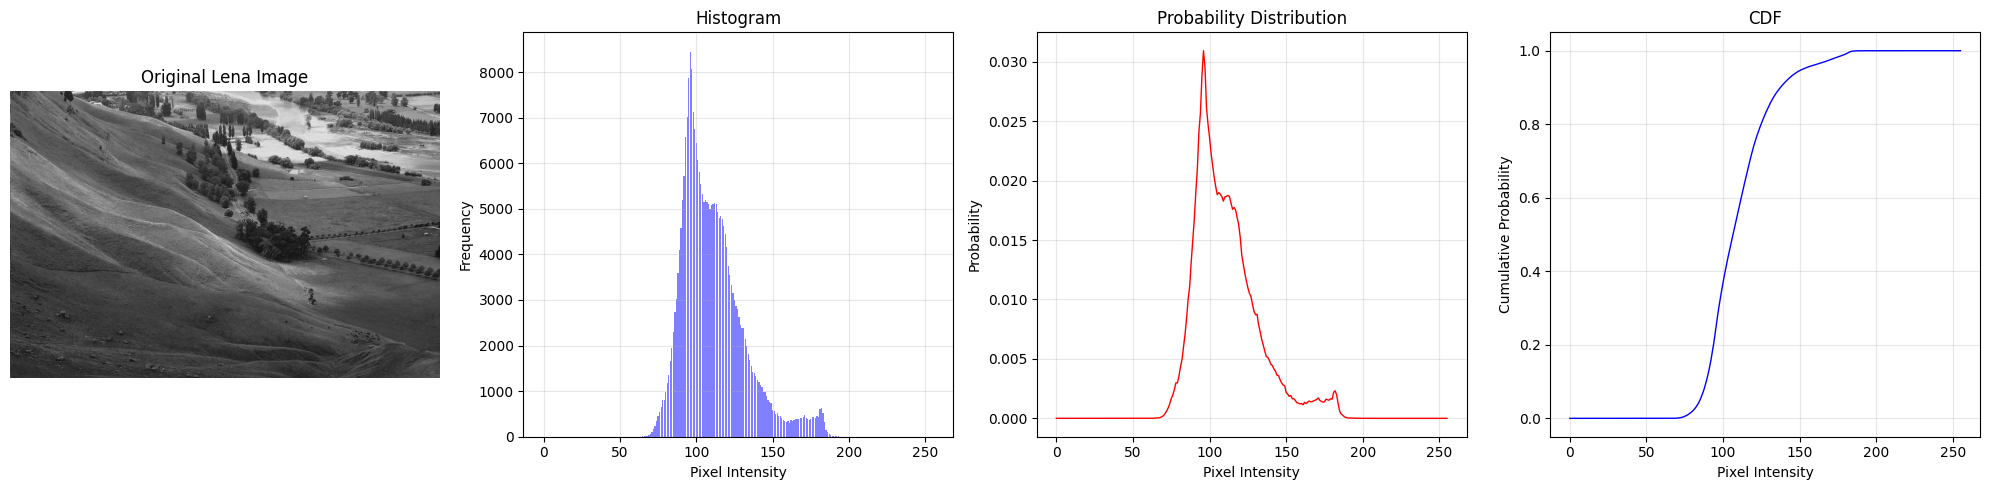

In [52]:
plt.figure(figsize=(20, 5))

# Original Lena image
plt.subplot(1, 4, 1)
plt.imshow(lena, cmap='gray')
plt.title('Original Lena Image')
plt.axis('off')

# Histogram
plt.subplot(1, 4, 2)
plt.bar(range(256), hist, color='blue', alpha=0.5)
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Probability distribution - outline only
plt.subplot(1, 4, 3)
plt.plot(range(256), prob, color='red', linewidth=1)
plt.title('Probability Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.grid(True, alpha=0.3)

plt.subplot(1, 4, 4)
plt.plot(range(256), cum_sum_array, color='blue', linewidth=1)
plt.title('CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
hist, prob, cum_sum_array, trans_fn, equalized, equalized_hist = histogram_equalization(equalized)

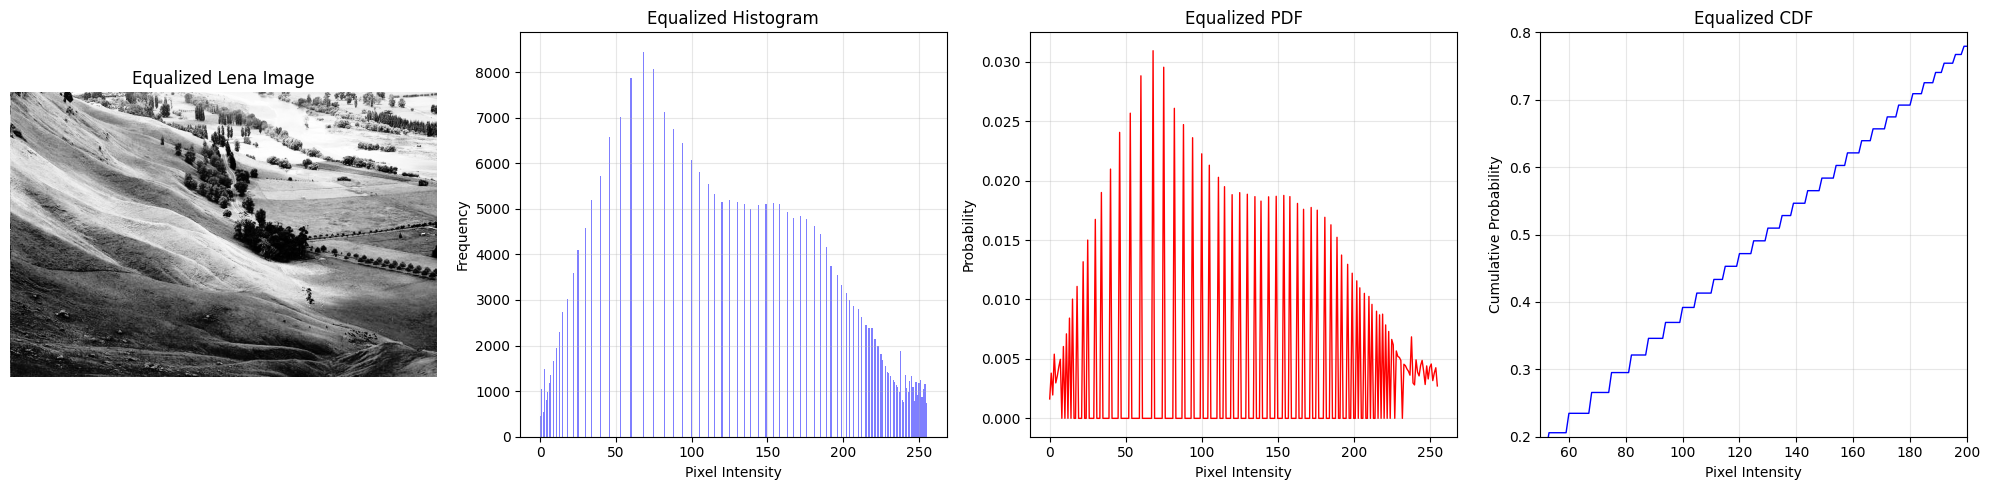

In [54]:
plt.figure(figsize=(20, 5))

# Equalized Lena image
plt.subplot(1, 4, 1)
plt.imshow(equalized, cmap='gray')
plt.title('Equalized Lena Image')
plt.axis('off')

# Equalized Histogram
plt.subplot(1, 4, 2)
plt.bar(range(256), equalized_hist, color='blue', alpha=0.5)
plt.title('Equalized Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Equalized Probability distribution (PDF) - outline only
plt.subplot(1, 4, 3)
plt.plot(range(256), prob, color='red', linewidth=1)
plt.title('Equalized PDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.grid(True, alpha=0.3)

# Equalized CDF
plt.subplot(1, 4, 4)
plt.plot(range(256), cum_sum_array, color='blue', linewidth=1)
plt.title('Equalized CDF')
plt.xlabel('Pixel Intensity')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.xlim(50, 200)  
plt.ylim(0.2, 0.8) 

plt.tight_layout()
plt.show()

In [55]:
b,g,r = cv2.split(resized_landscape)

In [56]:
hist_b, prob_b, cum_sum_array_b, trans_fn_b, equalized_b, equalized_hist_b = histogram_equalization(b)

In [57]:
cv2.imshow("Equalized Blue Channel", equalized_b)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [58]:
hist_g, prob_g, cum_sum_array_g, trans_fn_g, equalized_g, equalized_hist_g = histogram_equalization(g)

In [59]:
cv2.imshow("Equalized Blue Channel", equalized_b)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [60]:
hist_r, prob_r, cum_sum_array_r, trans_fn_r, equalized_r, equalized_hist_r = histogram_equalization(r)


In [61]:
cv2.imshow("Equalized Red Channel", equalized_r)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [62]:
final=cv2.merge((equalized_b, equalized_g, equalized_r))

In [63]:
cv2.imshow("Original", resized_landscape)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.imshow("Equalized Image", final)
cv2.waitKey(0)
cv2.destroyAllWindows()

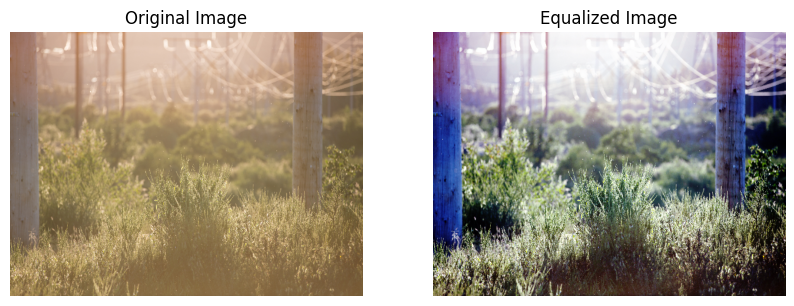

In [64]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(resized_landscape, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Equalized Image")
plt.imshow(cv2.cvtColor(final, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()